### Accelerated Picard algorithm

Known as Steffensen method. Take 2 Picard steps and interpolate. Repeat the process:

\begin{cases}
    x_1 = f(x_0) \\
    x_2 = f(x_1) \\
    x_3 = x_0 - \frac{(x_1 - x_0) ^ 2}{x_2 - 2 \, x_1 + x_0} \\
    x_0 = x_3 \\
    \text{repeat until convergence}
\end{cases}

As Picard, the upper bound of the absolute error can be computed as:

$$
    E_k < \frac{1}{1 - L} \, \left[ f(x_{k}) - x_k \right]
$$

Where $L$ is defined as:

$$
    L = \text{sup} \left| f'(x) \right| \quad \text{ for} \, x \in [a, b]
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def steffensen(f, f_prime, a, b, eps, N, n_grid, *args): # Implements the accelerated Picard algorithm with error upper bound

    # Estimate the contraction constant L of f on [a, b]
    grid = np.linspace(a, b, n_grid, endpoint = True)
    L = np.max(np.abs(f_prime(grid, *args)))

    if L >= 1.0:
        raise ValueError(f"Contraction constant L = {L} must be < 1")

    x = (a + b) / 2.0  # Start at the midpoint of [a, b]

    for j in range(N):
        
        fx  = f(x, *args)
        ffx = f(fx, *args)

        denom = ffx - 2.0 * fx + x

        if denom == 0.0:
            x_new = fx # Already at a fixed point (or degenerate step): fall back to Picard
        else:
            x_new = x - (fx - x) ** 2 / denom # Aitken's Delta^2 / Steffensen step

        err = abs(f(x_new, *args) - x_new) / (1.0 - L) # Rigorous a posteriori error bound on the *new* iterate

        if err < eps:
            print(f"Loop terminated at j = {j}. Error under the threshold")
            return x_new, err, L

        x = x_new

    # Maximum number of iterations reached: recompute residual at returned x
    print(f"Loop terminated at j = {N - 1}. Maximum number of iterations reached")
    err = abs(f(x, *args) - x) / (1.0 - L)

    return x, err, L

Let's apply it to the diode-resistance problem. Given a series diode-resistor circuit, the steady-state voltage drop acros a silicon diode is given implicity by:

$$
    V_{diode} = n \, V_T \, \ln \left(\frac{V_{gen} - V_{diode}}{R \, I_s} + 1 \right)
$$

In this form, the fixed-problem equation can be solved using Picard method (accelerated)

In [3]:
def voltage_diode(V_d, V_g, R, I_s, n, V_T): # Right hand side of the fixed problem equation
    return n * V_T * np.log((V_g - V_d) / (R * I_s) + 1.0)

def voltage_diode_prime(V_d, V_g, R, I_s, n, V_T): # Derivative to compute L
    return - n * V_T / (V_g - V_d + R * I_s)

In [4]:
# Realistic values
V_g = 5.0 # V generator
R = 5_000.0 # Resistance value
I_s = 2.52e-09 # Saturation current
n = 1.75 # Quality factor
V_T = 25.4e-03 # Thermal voltage

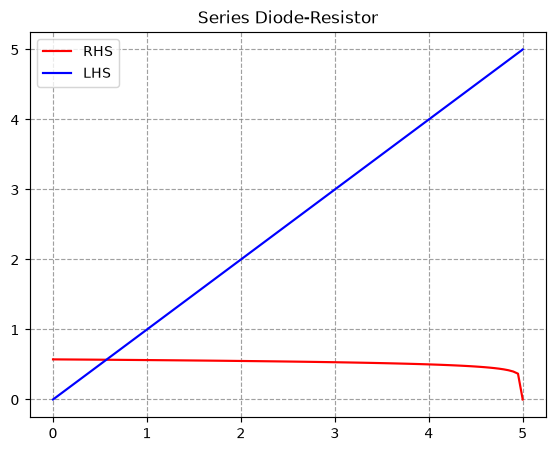

In [5]:
# Plotting to find a suitable starting range
V_d_array = np.linspace(0.0, V_g, 100)
plt.plot(V_d_array, voltage_diode(V_d_array, V_g, R, I_s, n, V_T), label = "RHS", color = 'red')
plt.plot(V_d_array, V_d_array, label = "LHS", color = 'blue')
plt.title('Series Diode-Resistor')
plt.legend(loc = 'best')
plt.grid(True, linestyle = '--', alpha = 0.75, color = 'gray')
plt.show()

In [6]:
V_d, err_v, L = steffensen(voltage_diode, voltage_diode_prime, 0.0, 1.0, 1e-06, 20, 100, V_g, R, I_s, n, V_T)

V_d * (10.0 ** 3), err_v * (10.0 ** 3), L # V_diode with absolute error [mV] and estimated L

Loop terminated at j = 0. Error under the threshold


(np.float64(567.6595354505142),
 np.float64(5.160750089501936e-05),
 np.float64(0.011112464995735262))

In [7]:
i, err_i = (V_g - V_d) / R, err_v / R # Current with absolute error (error propagation formula) [uA]
i * (10.0 ** 6), err_i * (10.0 ** 6)

(np.float64(886.4680929098972), np.float64(1.0321500179003872e-05))

Result:

$$
    V_D = 567,65954 \pm 0.00005 \, \, mV \qquad I = 886,46809 \pm 0.00001 \, \, \mu A
$$